# Week 11 — Bayesian Optimization

In [17]:
import numpy as np
import warnings
import sys
import importlib
sys.path.append('..')

import utils.bayesian_optimization
importlib.reload(utils.bayesian_optimization)
from utils.bayesian_optimization import propose_next_point, fit_gp, get_strategy

from utils.data_utils import (
    load_week_data,
    save_week_data,
    combine_with_week_results, 
    print_data_summary
)

## 1. Load Week 10 Data & Add Results

In [18]:
inputs, outputs = load_week_data("../week 10/week10_clean_data.npz")
print_data_summary(inputs, outputs, "Week 10 Data")

# Week 10 submitted points
week10_inputs = {
    1: np.array([0.423000, 0.425000]),
    2: np.array([0.450000, 0.500000]),
    3: np.array([0.347863, 0.672420, 0.443172]),
    4: np.array([0.408690, 0.367443, 0.360391, 0.408441]),
    5: np.array([0.500000, 0.500000, 0.500000, 0.500000]),
    6: np.array([0.755469, 0.275580, 0.644099, 0.672428, 0.162862]),
    7: np.array([0.000000, 0.309263, 0.707844, 0.246481, 0.405689, 0.758028]),
    8: np.array([0.107475, 0.120302, 0.070000, 0.207071, 1.000000, 0.099881, 0.180000, 0.998620])
}

# Week 10 outputs
week10_outputs = {
    1: 0.9648350956123805,
    2: 0.19454340426931843,
    3: -0.0046155839830820155,
    4: 0.6729775563203373,
    5: 32.0025,
    6: -0.5934759757958652,
    7: 1.8741934376204954,
    8: 9.788164173904
}

inputs, outputs = combine_with_week_results(inputs, outputs, week10_inputs, week10_outputs)
print_data_summary(inputs, outputs, "After Week 10 Results")


Data loaded from ../week 10/week10_clean_data.npz

Week 10 Data:
  Function 1: 19 points, 2D, best = 0.899216
  Function 2: 19 points, 2D, best = 0.613847
  Function 3: 24 points, 3D, best = -0.005640
  Function 4: 39 points, 4D, best = 0.724314
  Function 5: 29 points, 4D, best = 8662.482500
  Function 6: 29 points, 5D, best = -0.520742
  Function 7: 39 points, 6D, best = 1.869613
  Function 8: 49 points, 8D, best = 9.774664

After Week 10 Results:
  Function 1: 20 points, 2D, best = 0.964835
  Function 2: 20 points, 2D, best = 0.613847
  Function 3: 25 points, 3D, best = -0.004616
  Function 4: 40 points, 4D, best = 0.724314
  Function 5: 30 points, 4D, best = 8662.482500
  Function 6: 30 points, 5D, best = -0.520742
  Function 7: 40 points, 6D, best = 1.874193
  Function 8: 50 points, 8D, best = 9.788164


In [19]:
save_week_data(inputs, outputs, "week11_clean_data.npz")


Data saved to week11_clean_data.npz


## 2. Week 10 Results Analysis

In [20]:
print("=" * 70)
print("WEEK 10 RESULTS ANALYSIS")
print("=" * 70)

best_before = {}
for fid in range(1, 9):
    best_before[fid] = np.max(outputs[fid][:-1])

print(f"\n{'F':>2} {'Dims':>4} {'Best Before W10':>15} {'W10 Query':>14} {'New Best':>14} {'Status'}")
print("-" * 75)

improved = 0
for fid in range(1, 9):
    dim = inputs[fid].shape[1]
    prev_best = best_before[fid]
    w10_val = week10_outputs[fid]
    new_best = np.max(outputs[fid])
    
    if w10_val >= prev_best:
        status = "NEW BEST"
        improved += 1
    else:
        status = f"miss (best still {prev_best:.4f})"
    
    print(f"{fid:>2} {dim:>3}D {prev_best:>15.4f} {w10_val:>14.4f} {new_best:>14.4f}   {status}")

print(f"\nWeek 10 hit rate: {improved}/8 functions improved")
print("=" * 70)

WEEK 10 RESULTS ANALYSIS

 F Dims Best Before W10      W10 Query       New Best Status
---------------------------------------------------------------------------
 1   2D          0.8992         0.9648         0.9648   NEW BEST
 2   2D          0.6138         0.1945         0.6138   miss (best still 0.6138)
 3   3D         -0.0056        -0.0046        -0.0046   NEW BEST
 4   4D          0.7243         0.6730         0.7243   miss (best still 0.7243)
 5   4D       8662.4825        32.0025      8662.4825   miss (best still 8662.4825)
 6   5D         -0.5207        -0.5935        -0.5207   miss (best still -0.5207)
 7   6D          1.8696         1.8742         1.8742   NEW BEST
 8   8D          9.7747         9.7882         9.7882   NEW BEST

Week 10 hit rate: 4/8 functions improved


In [21]:
# Detailed strategy evaluation
print("=" * 70)
print("WEEK 10 STRATEGY EVALUATION")
print("=" * 70)

strategies = {
    1: ("BIGGER STEP dim2+0.010", "NEW BEST +0.066 (0.899→0.965). Massive win! Double step gave 3x bigger gain than any +0.005."),
    2: ("MID-GAP [0.45, 0.50]", "MISS 0.195. Better than dim1=0.20 (-0.001) but still far from peak. Second peak not in 0.20-0.68 gap either."),
    3: ("REVERSE dim3+0.004", "NEW BEST! -0.0046 vs -0.0056. Broke 5-week plateau! dim3 increase is the right direction."),
    4: ("TWO FRESH DIMS dim1&dim4 -0.005", "MISS 0.673 vs best 0.724. Multi-dim move regressed. Revert to single-dim from best."),
    5: ("DEAD CENTRE [0.5,0.5,0.5,0.5]", "INFO: 32.0025. Corner [1,1,1,1]=8662 is 270x better. Centre is not competitive."),
    6: ("ULTRA-SENSITIVE dim4+0.0002", "MISS -0.593 vs best -0.521. dim4 increase was wrong direction. Try dim4-0.0002 next."),
    7: ("ACCELERATE dim2-0.003", "NEW BEST +0.005 (1.870→1.874). 5th consecutive! Acceleration worked."),
    8: ("BOLD dim3+0.030", "NEW BEST +0.013 (9.775→9.788). 2nd consecutive dim3 gain. Closing peer gap (0.17 remaining).")
}

for fid in range(1, 9):
    strategy, evaluation = strategies[fid]
    print(f"\nF{fid}: {strategy}")
    print(f"  → {evaluation}")

print(f"\n{'=' * 70}")
print("SUMMARY: 4/8 new bests (F1, F3, F7, F8) — best week since W6!")
print("Winners: F1 double step, F3 dim3 reverse, F7 accelerated, F8 bold dim3")
print("=" * 70)

WEEK 10 STRATEGY EVALUATION

F1: BIGGER STEP dim2+0.010
  → NEW BEST +0.066 (0.899→0.965). Massive win! Double step gave 3x bigger gain than any +0.005.

F2: MID-GAP [0.45, 0.50]
  → MISS 0.195. Better than dim1=0.20 (-0.001) but still far from peak. Second peak not in 0.20-0.68 gap either.

F3: REVERSE dim3+0.004
  → NEW BEST! -0.0046 vs -0.0056. Broke 5-week plateau! dim3 increase is the right direction.

F4: TWO FRESH DIMS dim1&dim4 -0.005
  → MISS 0.673 vs best 0.724. Multi-dim move regressed. Revert to single-dim from best.

F5: DEAD CENTRE [0.5,0.5,0.5,0.5]
  → INFO: 32.0025. Corner [1,1,1,1]=8662 is 270x better. Centre is not competitive.

F6: ULTRA-SENSITIVE dim4+0.0002
  → MISS -0.593 vs best -0.521. dim4 increase was wrong direction. Try dim4-0.0002 next.

F7: ACCELERATE dim2-0.003
  → NEW BEST +0.005 (1.870→1.874). 5th consecutive! Acceleration worked.

F8: BOLD dim3+0.030
  → NEW BEST +0.013 (9.775→9.788). 2nd consecutive dim3 gain. Closing peer gap (0.17 remaining).

SUMMA

## 3. Sensitivity Analysis


Function 1 (2D) - Sensitivity Analysis
Baseline (best point): [0.423 0.425]
Baseline output: 0.964835

Dimension 1: Max gradient = 0.2870 (flat - less important)
Dimension 2: Max gradient = 0.3461 (flat - less important)


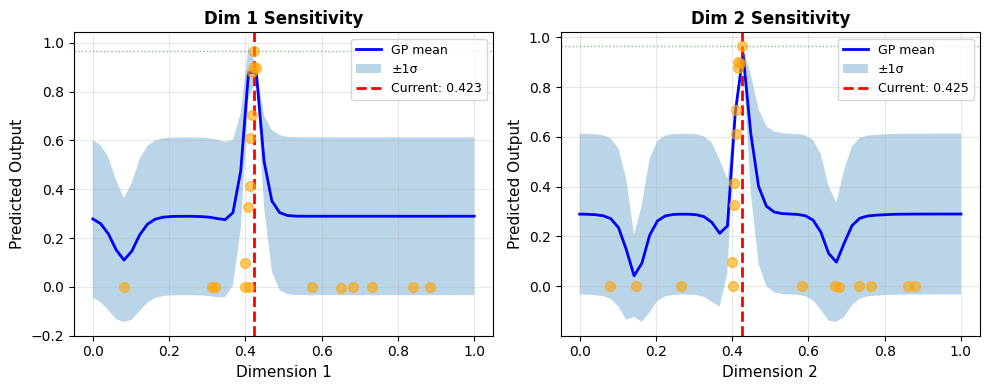



Function 2 (2D) - Sensitivity Analysis
Baseline (best point): [0.700073 0.125362]
Baseline output: 0.613847

Dimension 1: Max gradient = 0.1844 (flat - less important)
Dimension 2: Max gradient = 0.0000 (flat - less important)


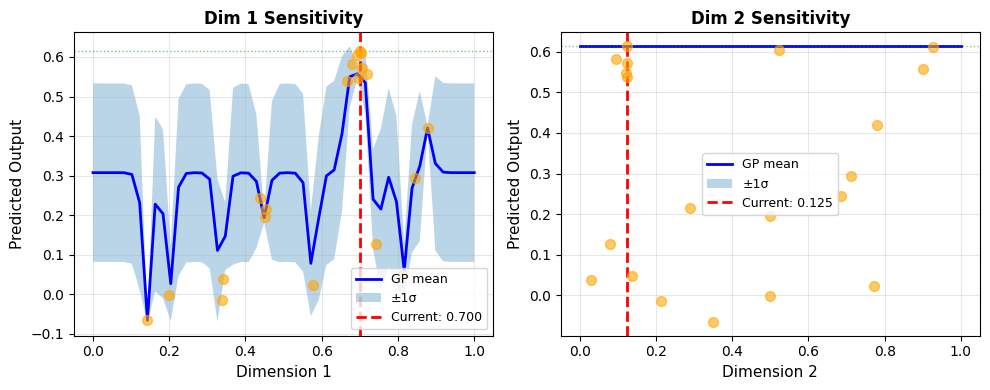



Function 3 (3D) - Sensitivity Analysis
Baseline (best point): [0.347863 0.67242  0.443172]
Baseline output: -0.004616

Dimension 1: Max gradient = 0.0371 (flat - less important)
Dimension 2: Max gradient = 0.0000 (flat - less important)
Dimension 3: Max gradient = 0.0187 (flat - less important)


/opt/homebrew/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


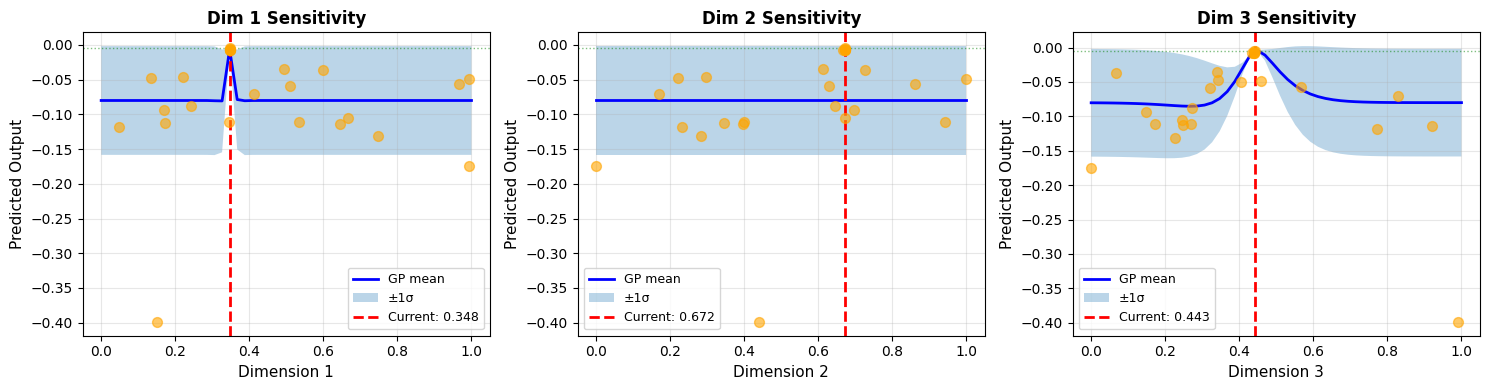



Function 4 (4D) - Sensitivity Analysis
Baseline (best point): [0.41369  0.367443 0.360391 0.413441]
Baseline output: 0.724314

Dimension 1: Max gradient = 0.6116 (flat - less important)
Dimension 2: Max gradient = 1.4449 (steep - important)
Dimension 3: Max gradient = 0.4683 (flat - less important)
Dimension 4: Max gradient = 0.6477 (flat - less important)


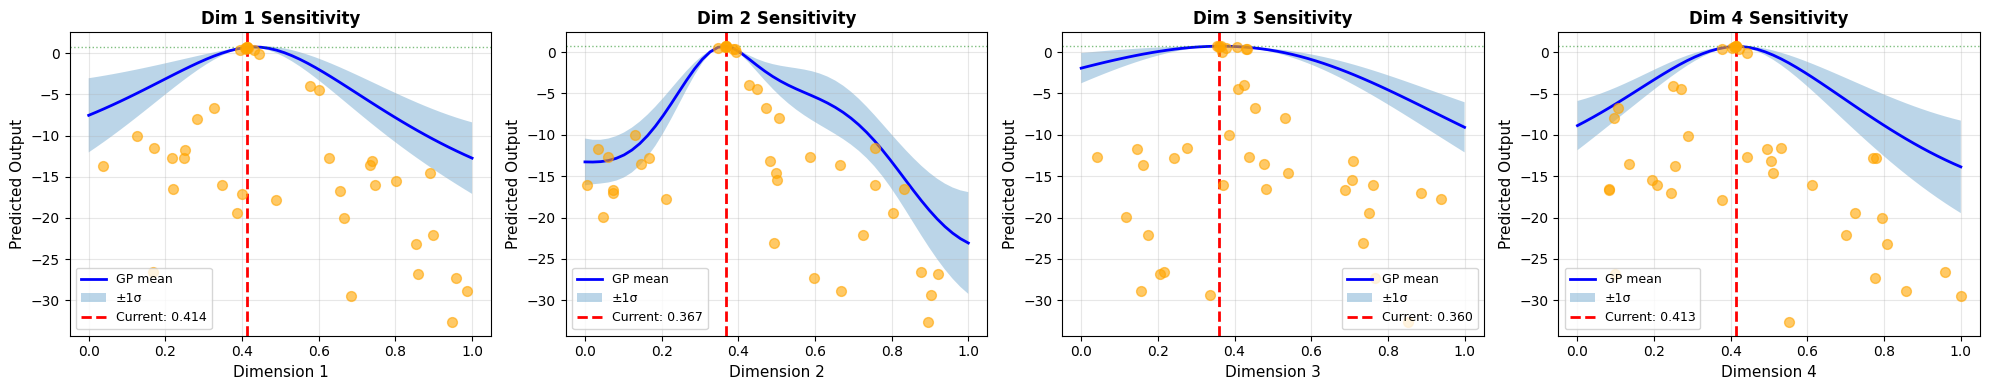



Function 5 (4D) - Sensitivity Analysis
Baseline (best point): [1. 1. 1. 1.]
Baseline output: 8662.482500

Dimension 1: Max gradient = 353.5197 (steep - important)
Dimension 2: Max gradient = 90.0115 (steep - important)
Dimension 3: Max gradient = 371.6935 (steep - important)
Dimension 4: Max gradient = 88.2963 (steep - important)


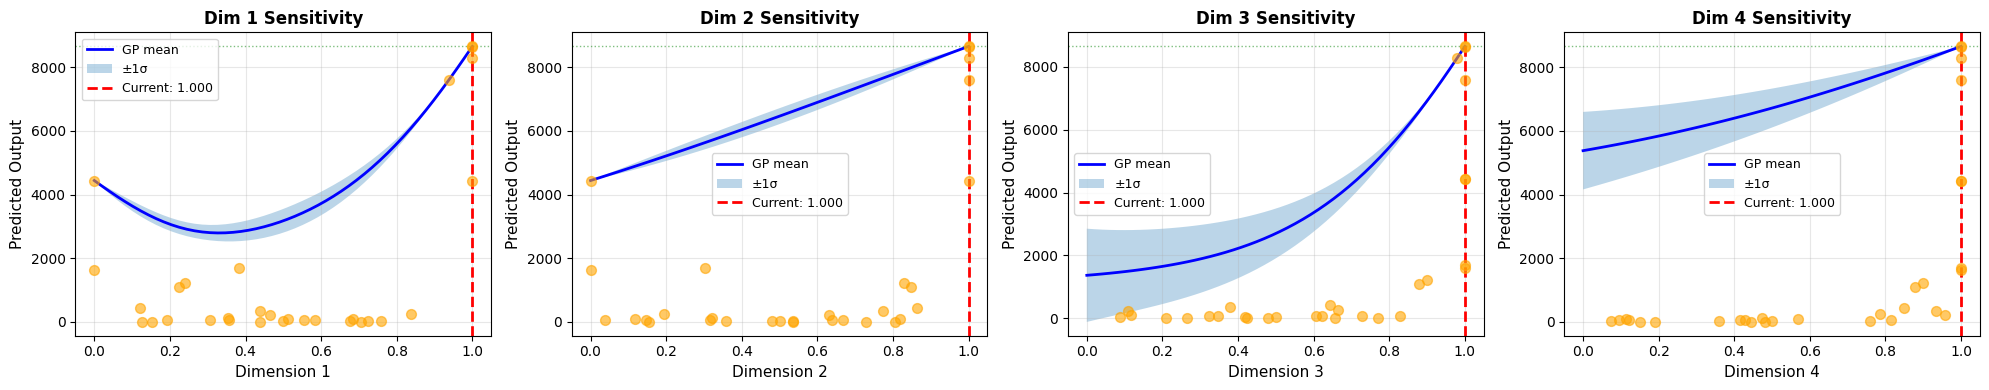



Function 6 (5D) - Sensitivity Analysis
Baseline (best point): [0.755469 0.27558  0.644099 0.672228 0.162862]
Baseline output: -0.520742

Dimension 1: Max gradient = 0.0181 (flat - less important)
Dimension 2: Max gradient = 0.3233 (flat - less important)
Dimension 3: Max gradient = 0.0000 (flat - less important)
Dimension 4: Max gradient = 0.1367 (flat - less important)
Dimension 5: Max gradient = 0.0859 (flat - less important)


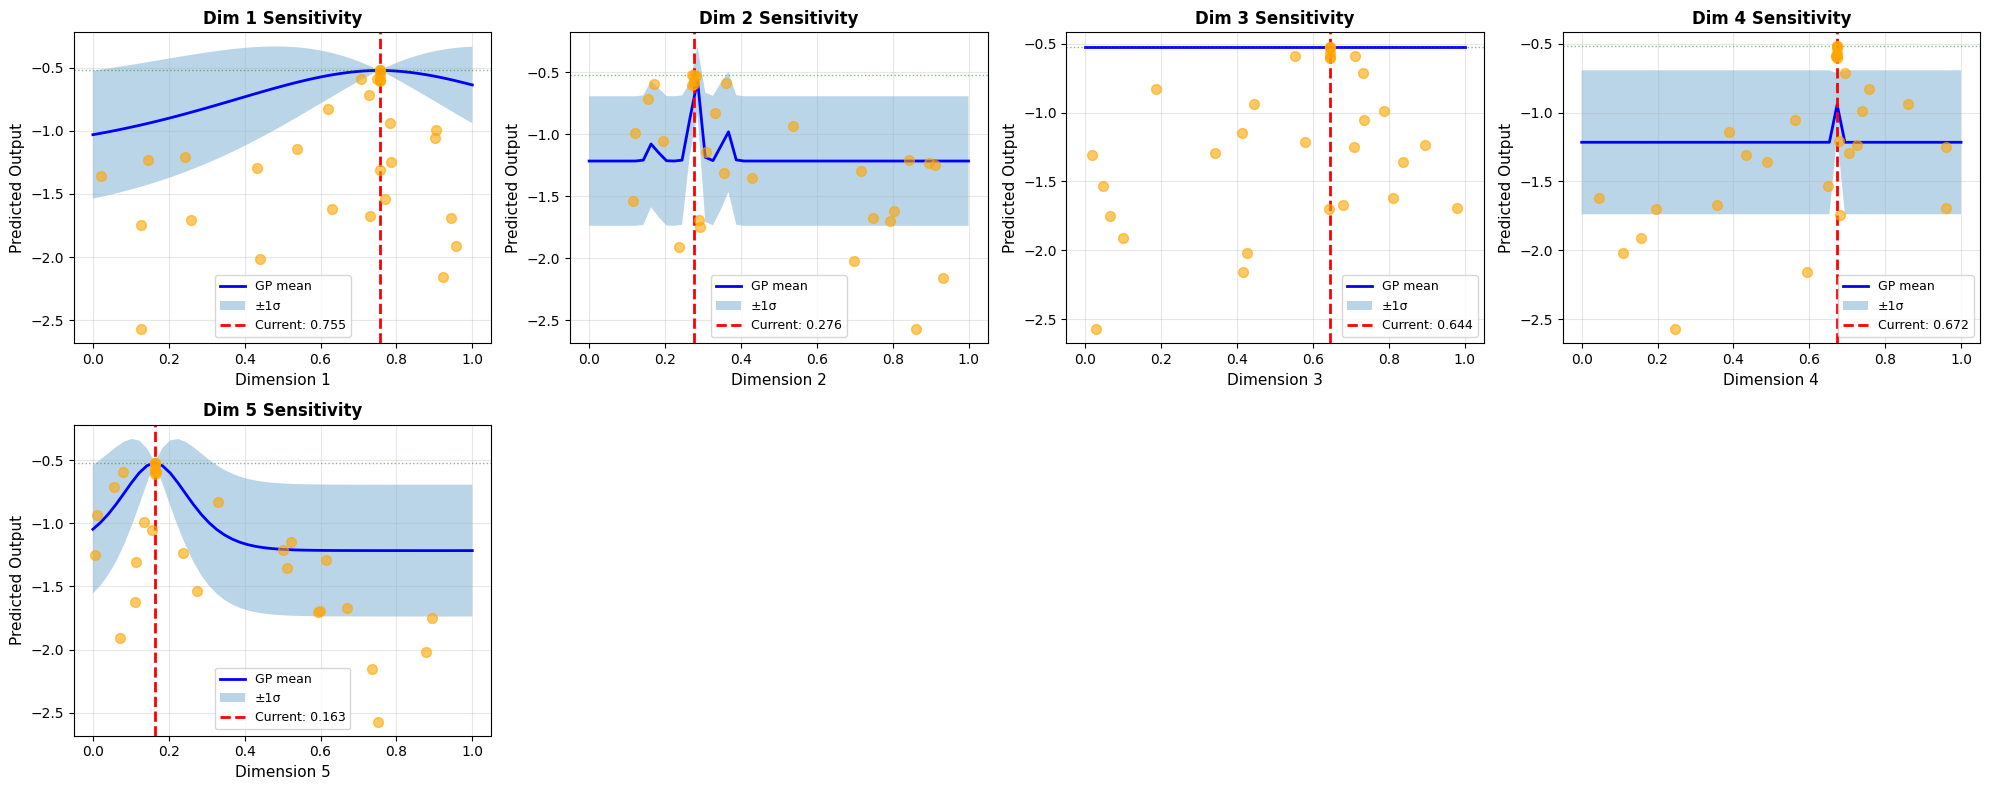



Function 7 (6D) - Sensitivity Analysis
Baseline (best point): [0.       0.309263 0.707844 0.246481 0.405689 0.758028]
Baseline output: 1.874193

Dimension 1: Max gradient = 0.0343 (flat - less important)
Dimension 2: Max gradient = 0.0819 (flat - less important)
Dimension 3: Max gradient = 0.0430 (flat - less important)
Dimension 4: Max gradient = 0.0418 (flat - less important)
Dimension 5: Max gradient = 0.0881 (flat - less important)
Dimension 6: Max gradient = 0.0650 (flat - less important)


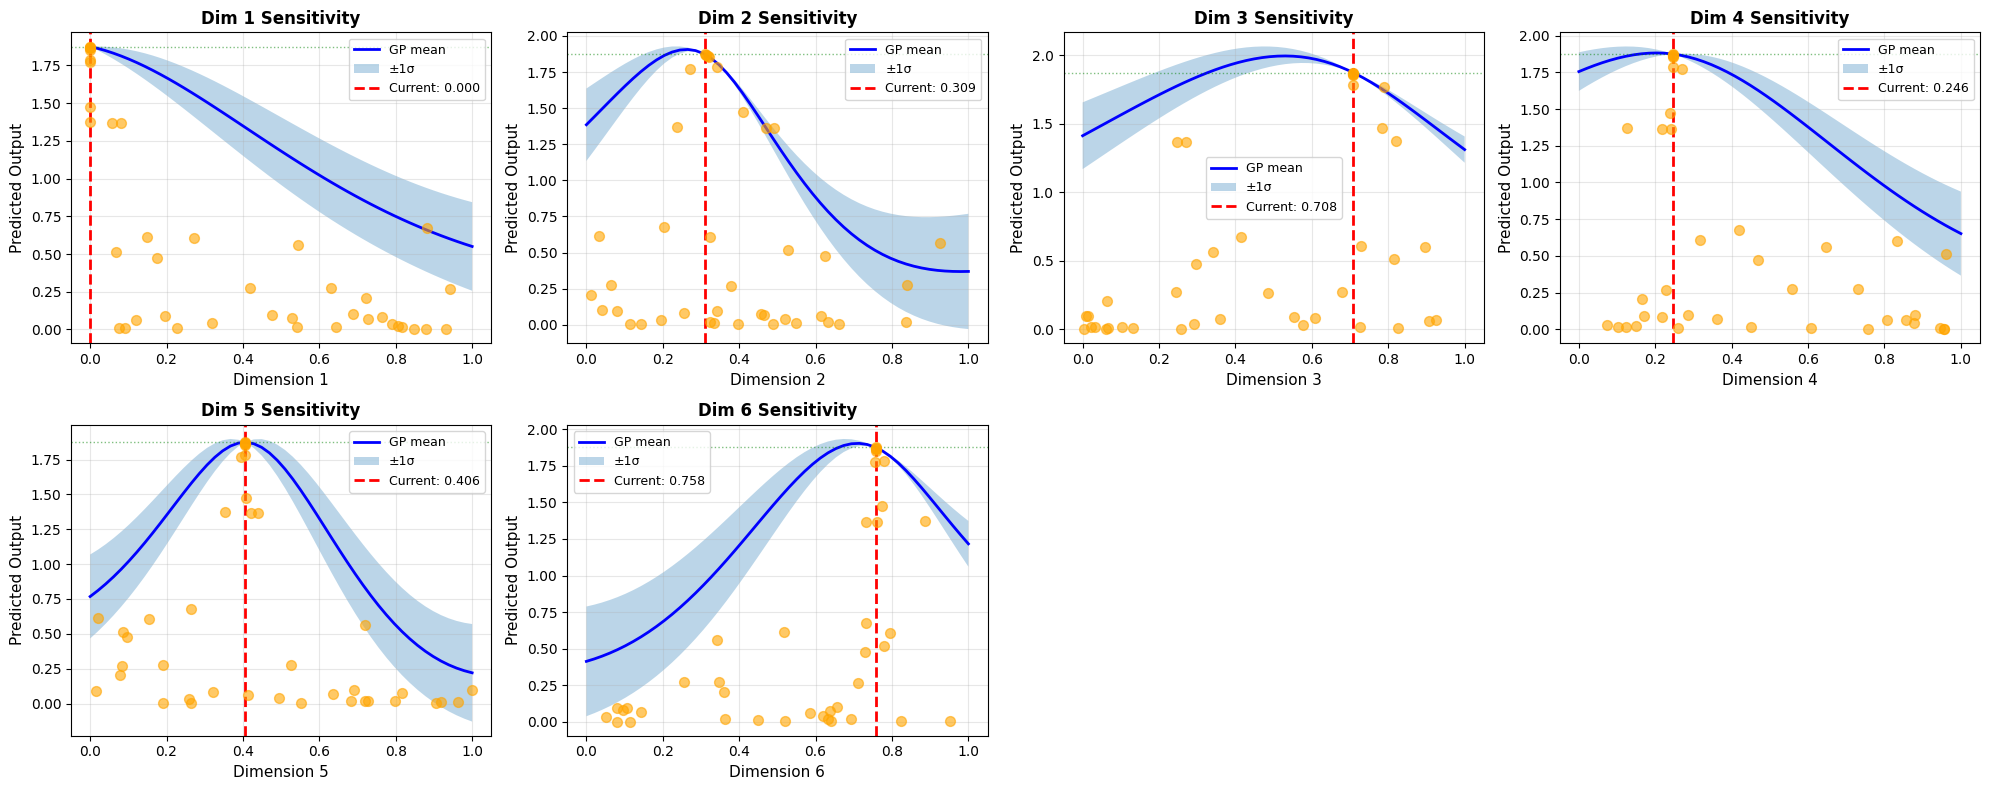



Function 8 (8D) - Sensitivity Analysis
Baseline (best point): [0.107475 0.120302 0.07     0.207071 1.       0.099881 0.18     0.99862 ]
Baseline output: 9.788164

Dimension 1: Max gradient = 0.0677 (flat - less important)
Dimension 2: Max gradient = 0.0298 (flat - less important)
Dimension 3: Max gradient = 0.0965 (flat - less important)
Dimension 4: Max gradient = 0.0196 (flat - less important)
Dimension 5: Max gradient = 0.0102 (flat - less important)
Dimension 6: Max gradient = 0.0237 (flat - less important)
Dimension 7: Max gradient = 0.0533 (flat - less important)
Dimension 8: Max gradient = 0.0000 (flat - less important)


/opt/homebrew/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


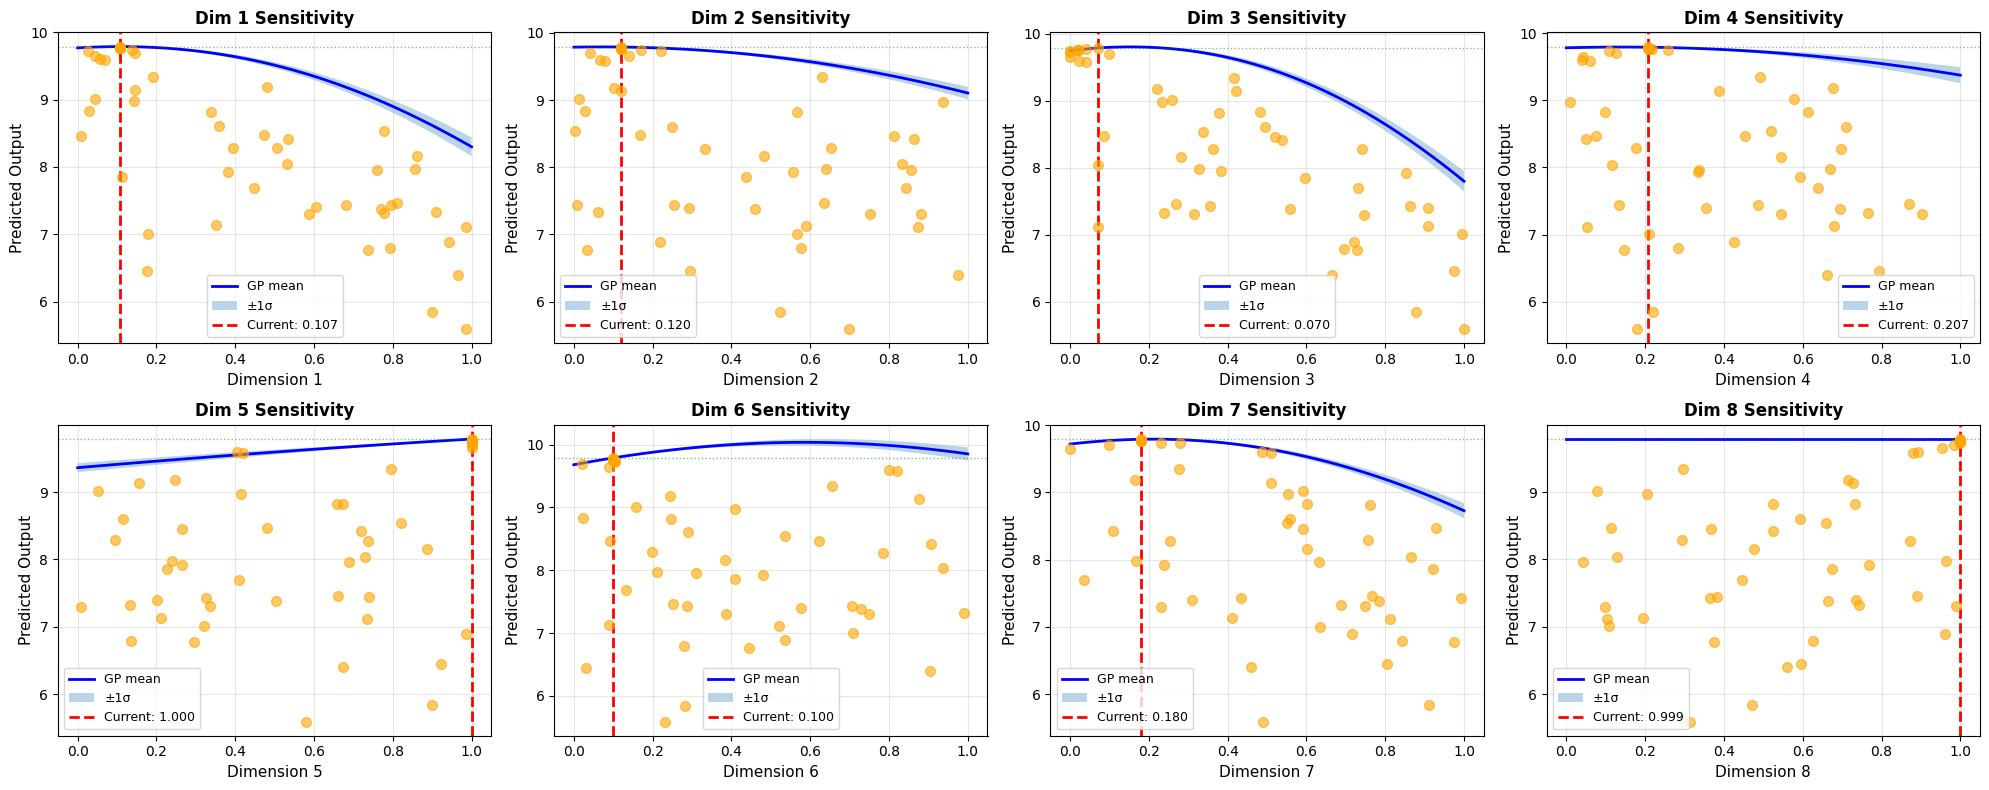

In [22]:
from utils.sensitivity import sensitivity_analysis

for func_id in range(1, 9):
    sensitivity_analysis(func_id, inputs[func_id], outputs[func_id])

## 4. Week 11 Strategy Design

### W10 key takeaways:
- **F1 double step = breakthrough** (+0.066). Keep doubling — try dim1+0.010 now.
- **F3 dim3+ direction confirmed**. Continue dim3 increase.
- **F7 5th consecutive best**. dim2-0.003 works. Keep going.
- **F8 dim3 streak continues** (+0.013). Keep pushing dim3+0.030.
- **F4 multi-dim failed**. Revert to single-dim from best point. dim2+0.005 (away from W6 failure at dim2=0.348).
- **F6 dim4+ was wrong**. Try dim4-0.0002.
- **F2** — 10 weeks stuck. dim1=0.20 dead, 0.45 dead. Only dim1=0.55-0.67 untested.

### Failure history check (all 80 previous submissions verified):
- **F1**: Large moves kill (W2: dim2+0.27→3.1e-39). Our +0.010 is safe (0.83 ls).
- **F4**: dim2=0.348 was bad in W6 (0.466). Go dim2+0.005→0.372 (away from failure).
- **F5**: Every deviation from [1,1,1,1] loses. Don't waste on tiny deviations — go bold [1,1,0,0] for info.
- **F7**: Danger zone at dim2=0.271 (W4). We're at 0.309→0.306 — 0.035 above.

### Strategy per function:

| F | Strategy | Rationale | Confidence |
|---|----------|-----------|------------|
| F1 | **dim1+0.010 → [0.433, 0.425]** | Alternate double step. W10 dim2+0.010 gave +0.066. | HIGH |
| F2 | **[0.55, 0.50]** — last unexplored gap | dim1=0.20 and 0.45 both dead. 0.55-0.67 last untested range. | LAST CHANCE |
| F3 | **dim3+0.004 → [0.348, 0.672, 0.447]** | W10 confirmed direction. Continue. | HIGH |
| F4 | **dim2+0.005 → [0.414, 0.372, 0.360, 0.413]** | Away from W6 failure (dim2=0.348). Fresh dim, safe direction. | MODERATE |
| F5 | **[1, 1, 0, 0]** — bold exploration | Best locked. Dims 3&4 at zero never tested. Max info gain. | BOLD |
| F6 | **dim4-0.0002** | W10 dim4+0.0002 failed. Reverse direction. Same controlled step. | MODERATE |
| F7 | **dim2-0.003 → [0.0, 0.306, ...]** | 5 consecutive bests. Still 0.035 above danger zone. | HIGH |
| F8 | **dim3+0.030 → [0.107, 0.120, 0.100, ...]** | Two consecutive wins. Total move = 0.043 length scales. | HIGH |

In [23]:
import warnings
import importlib
import utils.bayesian_optimization
importlib.reload(utils.bayesian_optimization)
from utils.bayesian_optimization import fit_gp, propose_next_point

week11_recommendations = {}

def get_best_point(fid):
    best_idx = np.argmax(outputs[fid])
    return inputs[fid][best_idx].copy()

# ============================================================
# F1: DOUBLE STEP dim1+0.010 (alternate from W10's dim2+0.010)
# W10's dim2+0.010 gave +0.066. Now alternate to dim1.
# dim1 ls=0.012, so +0.010 = 0.83 length scales (safe)
# CHECKED: W2's disaster was dim2+0.27 (huge). +0.010 is safe.
# ============================================================
best1 = get_best_point(1)  # [0.423, 0.425] → 0.9648
week11_recommendations[1] = np.array([best1[0] + 0.010, best1[1]])

# ============================================================
# F2: LAST GAP — [0.55, 0.50]
# dim1=0.20→-0.001, 0.45→0.195, 0.68-0.81→peak 0.614.
# 0.55-0.67 is the ONLY remaining untested range.
# ============================================================
week11_recommendations[2] = np.array([0.550000, 0.500000])

# ============================================================
# F3: CONTINUE dim3+0.004
# W10 confirmed: dim3+ breaks plateau (-0.0056→-0.0046).
# Continue same direction and step.
# ============================================================
best3 = get_best_point(3)  # [0.347863, 0.672420, 0.443172] → -0.0046
week11_recommendations[3] = np.array([best3[0], best3[1], best3[2] + 0.004])

# ============================================================
# F4: SINGLE DIM — dim2+0.005 → 0.372 (AWAY from W6 failure)
# CHECKED: W6 had dim2=0.348→0.466 (bad). dim2-0.005→0.362 goes
# TOWARD that failure. Instead go dim2+0.005→0.372 (safe direction).
# ============================================================
best4 = get_best_point(4)  # [0.413690, 0.367443, 0.360391, 0.413441] → 0.7243
week11_recommendations[4] = np.array([best4[0], best4[1] + 0.005, best4[2], best4[3]])

# ============================================================
# F5: BOLD EXPLORATION — [1, 1, 0, 0]
# Best locked at [1,1,1,1]=8662. Every deviation from corner loses.
# Instead of wasting on tiny deviations, go BOLD:
# dims 1&2 maxed, dims 3&4 at zero. NEVER TESTED.
# Tells us exactly what dims 3&4 contribute when 1&2 are maxed.
# CHECKED: unique — no previous F5 submission had dims 3&4 at 0.
# ============================================================
week11_recommendations[5] = np.array([1.000000, 1.000000, 0.000000, 0.000000])

# ============================================================
# F6: REVERSE dim4-0.0002
# W10: dim4+0.0002 → -0.593 (worse than best -0.521).
# Try opposite direction. Same controlled 1/5 length scale step.
# CHECKED: Only dim4 changes. No multi-dim disaster risk.
# ============================================================
best6 = get_best_point(6)  # [0.755469, 0.275580, 0.644099, 0.672228, 0.162862] → -0.5207
week11_recommendations[6] = np.array([
    best6[0],
    best6[1],
    best6[2],
    best6[3] - 0.0002,   # dim4 -0.0002 (reverse of W10)
    best6[4]
])

# ============================================================
# F7: CONTINUE dim2-0.003 → 0.306
# 5 consecutive bests. Same accelerated step.
# CHECKED: 0.306 is still 0.035 above W4 danger zone (0.271).
# ============================================================
best7 = get_best_point(7)  # [0.0, 0.309263, ...] → 1.8742
week11_recommendations[7] = np.array([
    best7[0],
    best7[1] - 0.003,    # dim2 -0.003 (0.309→0.306)
    best7[2],
    best7[3],
    best7[4],
    best7[5]
])

# ============================================================
# F8: CONTINUE dim3+0.030 → 0.100
# Two consecutive wins (+0.012, +0.013). Keep pushing.
# CHECKED: Total dim3 move (0.020→0.100) = 0.043 length scales. Safe.
# ============================================================
best8 = get_best_point(8)  # [0.107, 0.120, 0.070, ...] → 9.788
week11_recommendations[8] = np.array([
    best8[0],
    best8[1],
    best8[2] + 0.030,    # dim3 +0.030 (0.070→0.100)
    best8[3],
    best8[4],
    best8[5],
    best8[6],
    best8[7]
])

# ============================================================
# Sanity check
# ============================================================
print("Week 11 Recommendations")
print("=" * 80)
for fid in range(1, 9):
    X, y = inputs[fid], outputs[fid]
    rec = week11_recommendations[fid]
    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        gp = fit_gp(X, y)
    pred, pred_std = gp.predict(rec.reshape(1, -1), return_std=True)
    dists = np.linalg.norm(X - rec, axis=1)
    min_dist = np.min(dists)
    best = np.max(y)
    
    strategy = {
        1: "DOUBLE STEP dim1+0.010 (alternate) — HIGH",
        2: "LAST GAP [0.55, 0.50] — LAST CHANCE",
        3: "CONTINUE dim3+0.004 (confirmed) — HIGH",
        4: "SAFE DIM dim2+0.005 → 0.372 (away from W6 failure) — MODERATE",
        5: "BOLD [1,1,0,0] — dims 3&4 at zero, never tested",
        6: "REVERSE dim4-0.0002 (W10 wrong direction) — MODERATE",
        7: "CONTINUE dim2-0.003 → 0.306 (6th best target) — HIGH",
        8: "CONTINUE dim3+0.030 → 0.100 (3rd consecutive) — HIGH"
    }
    
    print(f"F{fid} ({X.shape[1]}D)  best={best:.4f}  pred={pred[0]:.4f}±{pred_std[0]:.4f}  dist={min_dist:.4f}  {strategy[fid]}")
    print(f"  point: {rec}")
print("=" * 80)

Week 11 Recommendations
F1 (2D)  best=0.9648  pred=0.7912±0.0535  dist=0.0071  DOUBLE STEP dim1+0.010 (alternate) — HIGH
  point: [0.433 0.425]
F2 (2D)  best=0.6138  pred=0.2857±0.2248  dist=0.1000  LAST GAP [0.55, 0.50] — LAST CHANCE
  point: [0.55 0.5 ]
F3 (3D)  best=-0.0046  pred=-0.0042±0.0004  dist=0.0040  CONTINUE dim3+0.004 (confirmed) — HIGH
  point: [0.347863 0.67242  0.447172]
F4 (4D)  best=0.7243  pred=0.6833±0.0267  dist=0.0050  SAFE DIM dim2+0.005 → 0.372 (away from W6 failure) — MODERATE
  point: [0.41369  0.372443 0.360391 0.413441]
F5 (4D)  best=8662.4825  pred=1364.1572±1718.1498  dist=0.6487  BOLD [1,1,0,0] — dims 3&4 at zero, never tested
  point: [1. 1. 0. 0.]
F6 (5D)  best=-0.5207  pred=-0.4641±0.0234  dist=0.0002  REVERSE dim4-0.0002 (W10 wrong direction) — MODERATE
  point: [0.755469 0.27558  0.644099 0.672028 0.162862]
F7 (6D)  best=1.8742  pred=1.8780±0.0008  dist=0.0030  CONTINUE dim2-0.003 → 0.306 (6th best target) — HIGH
  point: [0.       0.306263 0.707844 

## 5. Submission Format

In [ ]:
print("=" * 70)
print("WEEK 11 SUBMISSION — COPY THESE VALUES")
print("=" * 70)

for fid in range(1, 9):
    pt = week11_recommendations[fid]
    formatted = '-'.join(f'{x:.6f}' for x in pt)
    print(f"Function {fid}:\t{formatted}")


WEEK 11 SUBMISSION — COPY THESE VALUES
Function 1:	0.433000-0.425000
Function 2:	0.550000-0.500000
Function 3:	0.347863-0.672420-0.447172
Function 4:	0.413690-0.372443-0.360391-0.413441
Function 5:	1.000000-1.000000-0.000000-0.000000
Function 6:	0.755469-0.275580-0.644099-0.672028-0.162862
Function 7:	0.000000-0.306263-0.707844-0.246481-0.405689-0.758028
Function 8:	0.107475-0.120302-0.100000-0.207071-1.000000-0.099881-0.180000-0.998620

SUBMISSION POINTS (array format)
Function 1:	[np.float64(0.433), np.float64(0.425)]
Function 2:	[np.float64(0.55), np.float64(0.5)]
Function 3:	[np.float64(0.347863), np.float64(0.67242), np.float64(0.447172)]
Function 4:	[np.float64(0.41369), np.float64(0.372443), np.float64(0.360391), np.float64(0.413441)]
Function 5:	[np.float64(1.0), np.float64(1.0), np.float64(0.0), np.float64(0.0)]
Function 6:	[np.float64(0.755469), np.float64(0.27558), np.float64(0.644099), np.float64(0.672028), np.float64(0.162862)]
Function 7:	[np.float64(0.0), np.float64(0.30